# 01 — Exploratory Data Analysis
Silver prices, macro covariates, and return series.


In [16]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from eda_utils import eda_transform

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load data

In [17]:
prices = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
macro  = pd.read_csv('../data/raw/monthly_macro.csv', index_col=0, parse_dates=True)

silver = prices['silver'].dropna()
print(prices.shape, macro.shape)
prices.head()

(2854, 6) (2991, 6)


,silver,gold,usd_index,sp500,tip_etf,copper
Date,,,,,,
2015-01-02,15.734000,1186.000000,91.080002,2058.199951,84.513382,2.8385
2015-01-05,16.179001,1203.900024,91.379997,2020.579956,84.580849,2.7930
2015-01-06,16.603001,1219.300049,91.500000,2002.609985,84.588341,2.8040
2015-01-07,16.510000,1210.599976,91.889999,2025.900024,84.655792,2.7960
2015-01-08,16.351000,1208.400024,92.370003,2062.139893,84.520889,2.8070


## 2. Silver price level

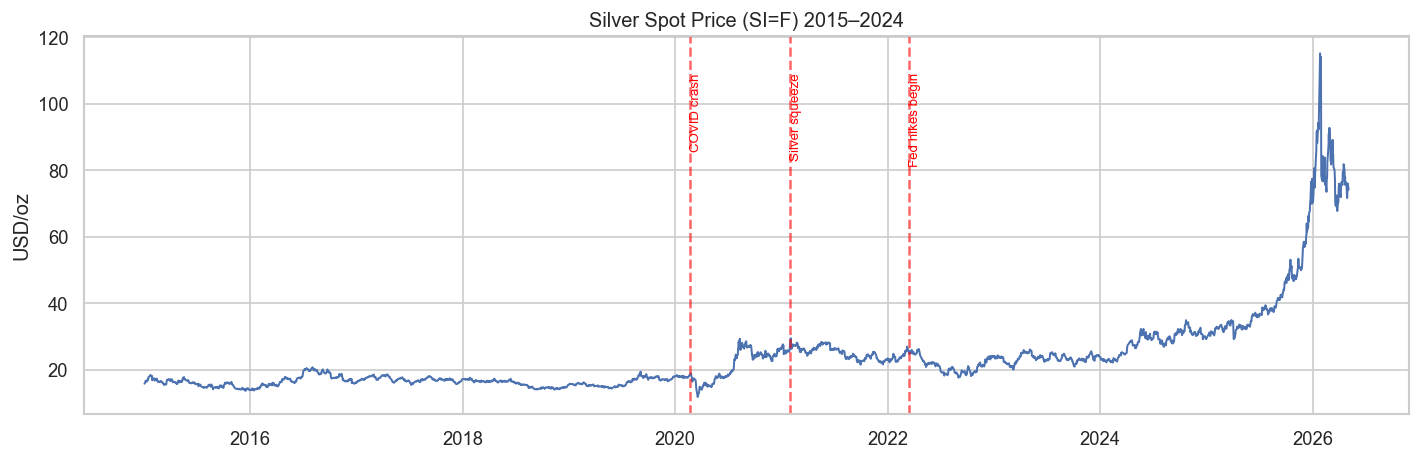

In [18]:
# Annotate key events
events = {
    'COVID crash': '2020-02-20',
    'Silver squeeze': '2021-01-28',
    'Fed hikes begin': '2022-03-16',
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(silver, lw=1.2, label='Silver (SI=F)')
for label, date in events.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.6)
    ax.text(pd.to_datetime(date), silver.max() * 0.95, label,
            rotation=90, fontsize=8, color='red', va='top')
ax.set_title('Silver Spot Price (SI=F) 2015–2024')
ax.set_ylabel('USD/oz')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. EDA on price level (expect non-stationary)

No transform applied.


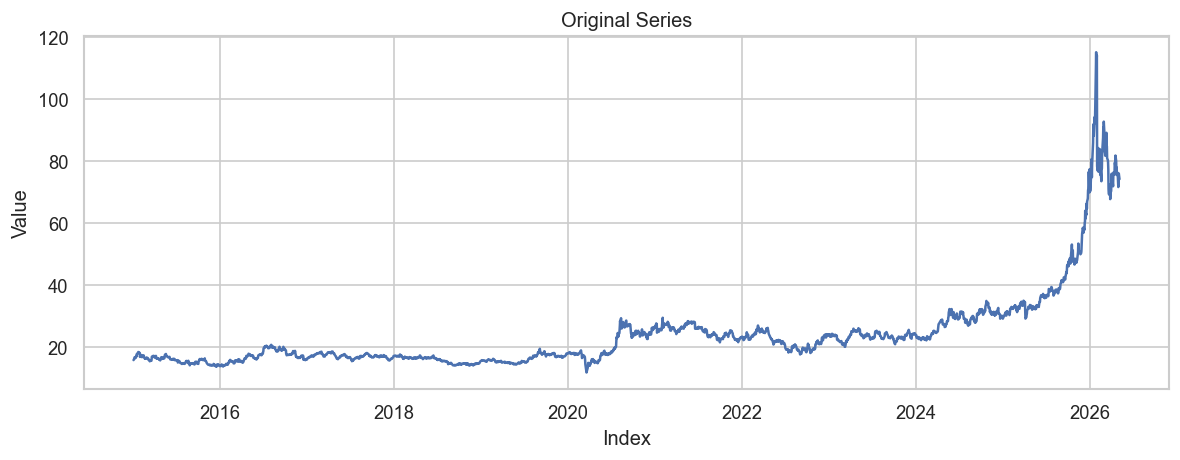

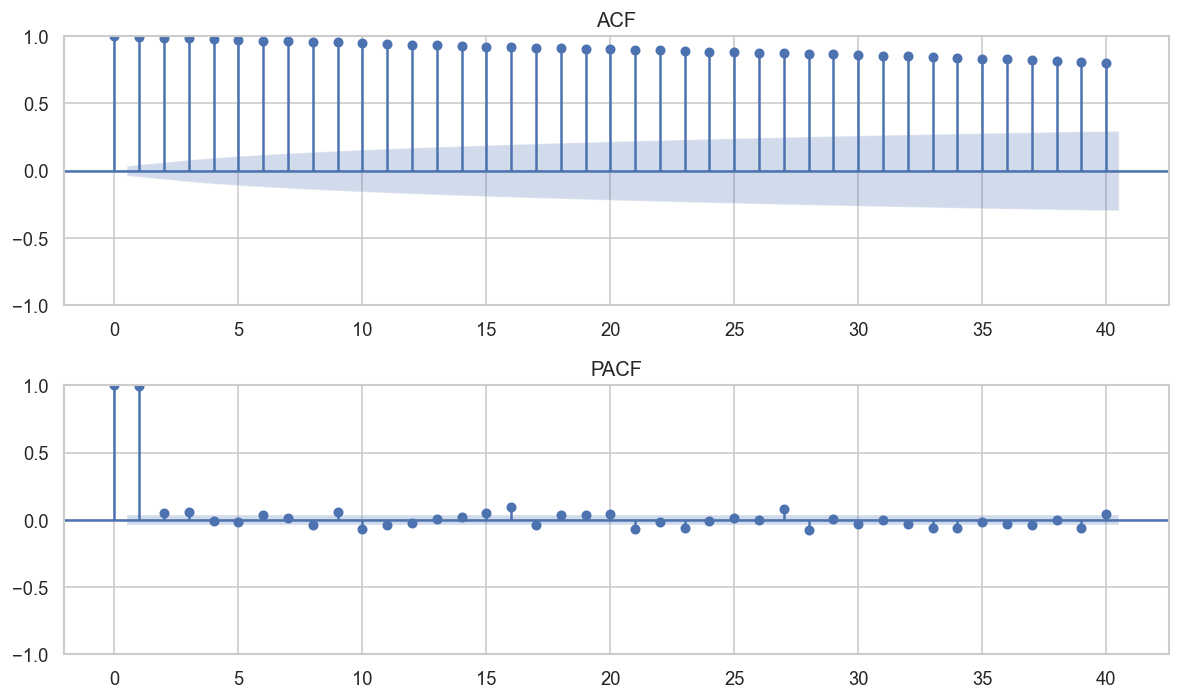

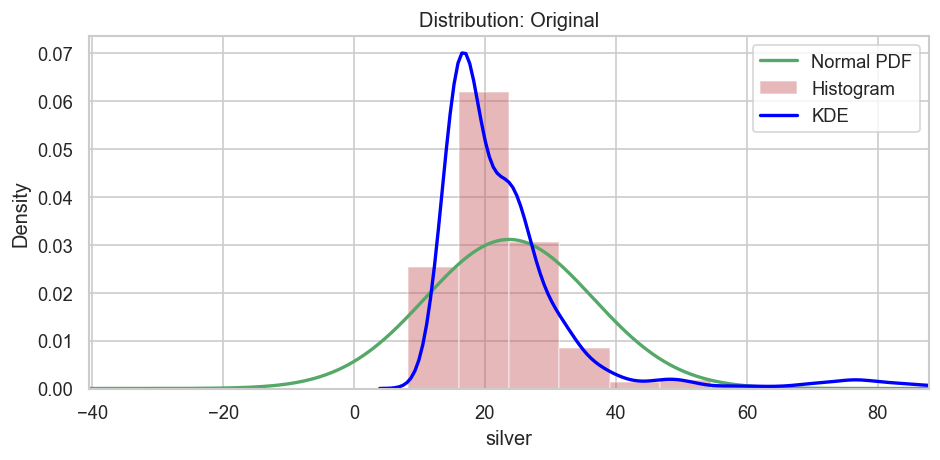

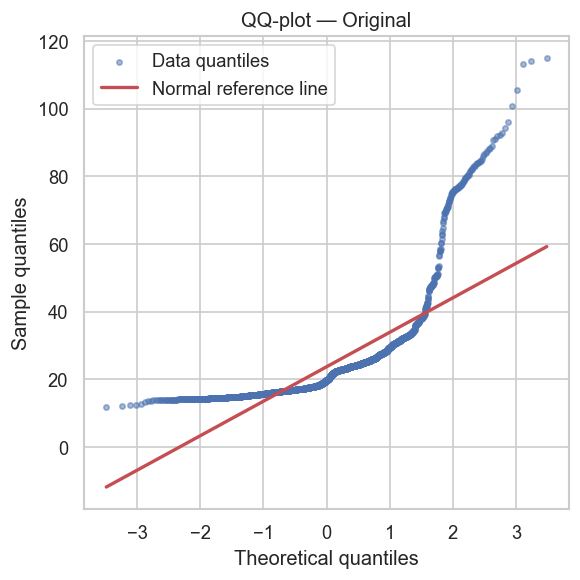

  QQ R²: 0.6308 (1.0 = perfect normal)

ADF Test:
  Statistic: 1.0816
  p-value:   0.9951
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Non-stationary (fail to reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.6313, p=0.0000  → NOT normal
D'Agostino K²:        stat=1980.3694, p=0.0000  → NOT normal
Anderson-Darling:     stat=279.7351
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.2172, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2724.57, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [19]:
result_level = eda_transform(silver, transform=None, lags=40)

## 4. EDA on log-returns (model input)

To answer the natural question — why not just use `.pct_change()` or `.diff()`?

Say silver closes at **\$16.18** on Monday and **\$16.60** on Tuesday.

| Transform | Formula | Result |
|---|---|---|
| `silver.diff()` | $p_t - p_{t-1} = 16.60 - 16.18$ | $+0.42$ (dollars, not a return) |
| `silver.pct_change()` | $(p_t - p_{t-1})/p_{t-1}$ | $+2.60\%$ (simple return $R_t$) |
| `np.log(silver).diff()` | $\ln(16.60) - \ln(16.18) = \ln(16.60/16.18)$ | $+0.0257$ (log return $r_t$) |

So `.diff()` alone gives a **dollar change**, not a return — it's price-level dependent and useless for comparing across assets or time.

**Why log returns over simple returns?**

1. **Time-additivity.** Suppose silver goes $16 \to 18 \to 15$. Log returns add: $\ln(18/16) + \ln(15/18) = \ln(15/16)$. Simple returns don't: $+12.5\%$ then $-16.7\%$ gives a net of $-6.25\%$, not $-4.17\%$ — you need to multiply $(1.125)(0.833) - 1$, which becomes unwieldy over many periods.

2. **Symmetry.** A price doubling ($r = +\ln 2 \approx +0.693$) and a price halving ($r = -\ln 2 \approx -0.693$) are equal in magnitude. In simple return space they are not: $+100\%$ up vs $-50\%$ down.

3. **Approximate normality.** Log returns are closer to Gaussian for daily horizons, which is what ARIMA and OLS assume. Price levels and dollar differences are non-stationary by construction.

For small daily moves $r_t \approx R_t$ (first-order Taylor: $\ln(1+R_t) \approx R_t$), so the two are nearly identical numerically day-to-day — the differences accumulate over longer horizons.

**A note on variance stability.** `.diff()` is also stationary and would show similar autocorrelation structure in the ACF — so stationarity alone doesn't justify the log transform. The variance-stabilisation argument (a \$0.42 move at \$16 vs \$25) is real but modest for silver's price range (\$14–\$30). The most defensible justification here is **convention**: log returns are the field default in financial econometrics, and what ARIMA/OLS residual assumptions are built around.

> **TODO:** Run a Levene or Bartlett test comparing variance stability of `silver.diff()` vs `np.log(silver).diff()` across subperiods (pre/post 2020, pre/post silver squeeze) to quantify whether the variance-stabilisation argument actually holds for this sample.

No transform applied.


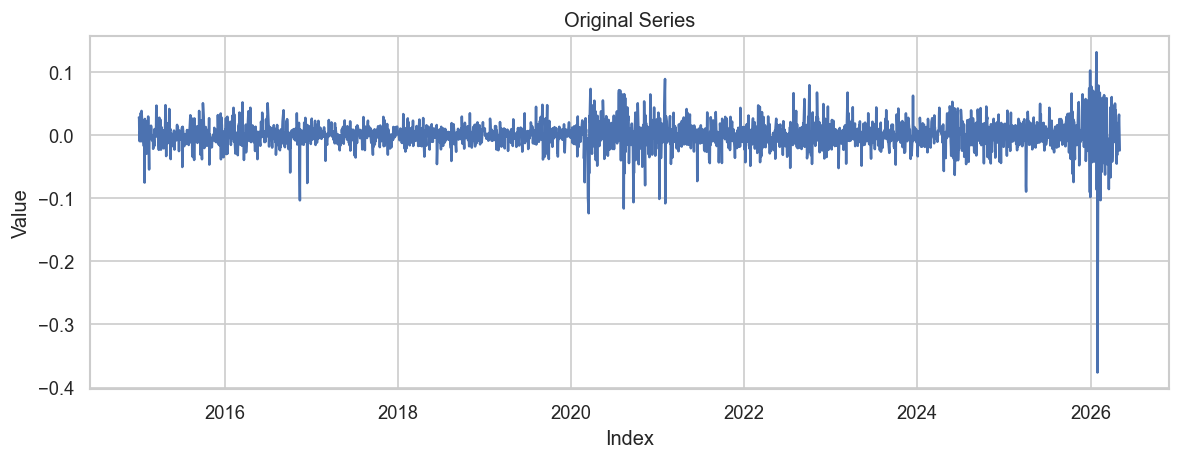

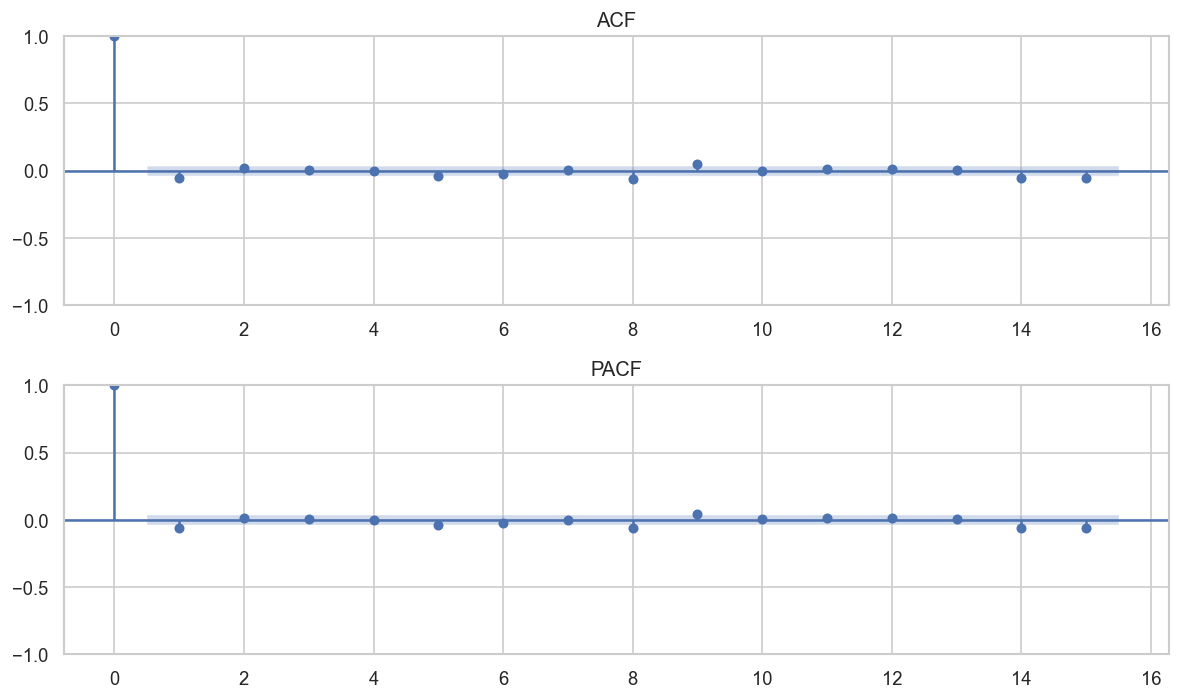

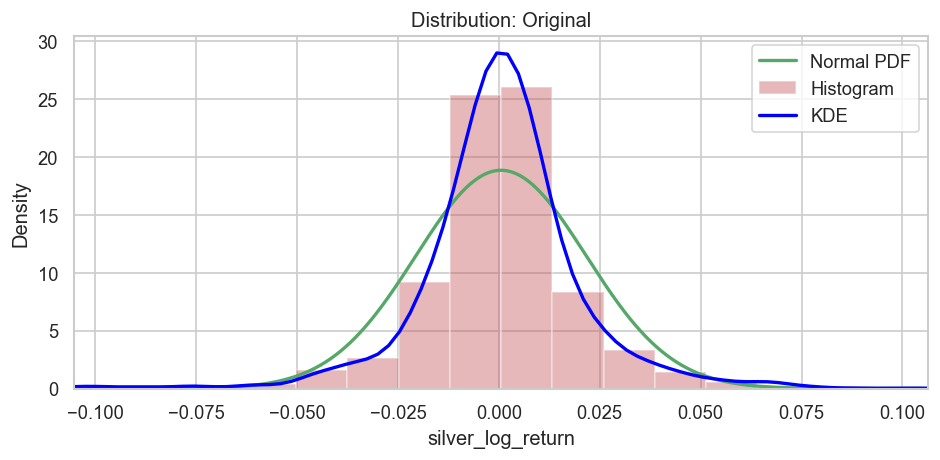

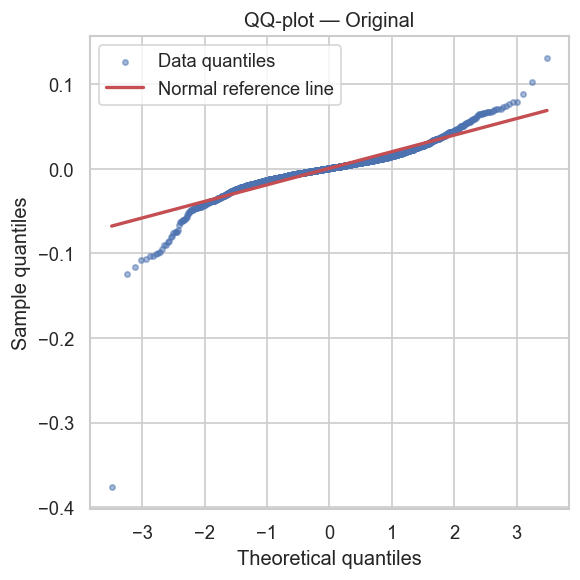

  QQ R²: 0.8542 (1.0 = perfect normal)

ADF Test:
  Statistic: -9.4869
  p-value:   0.0000
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Stationary (reject H₀)

Ljung-Box (lag=15): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.8572, p=0.0000  → NOT normal
D'Agostino K²:        stat=1846.3017, p=0.0000  → NOT normal
Anderson-Darling:     stat=64.7974
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.0974, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=135.80, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=15): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [20]:
log_returns = np.log(silver).diff().dropna()
log_returns.name = 'silver_log_return'
result_returns = eda_transform(log_returns, transform=None, lags=15)

In [21]:
# log_returns already computed above — nothing to repeat here

## 5. Covariate overview

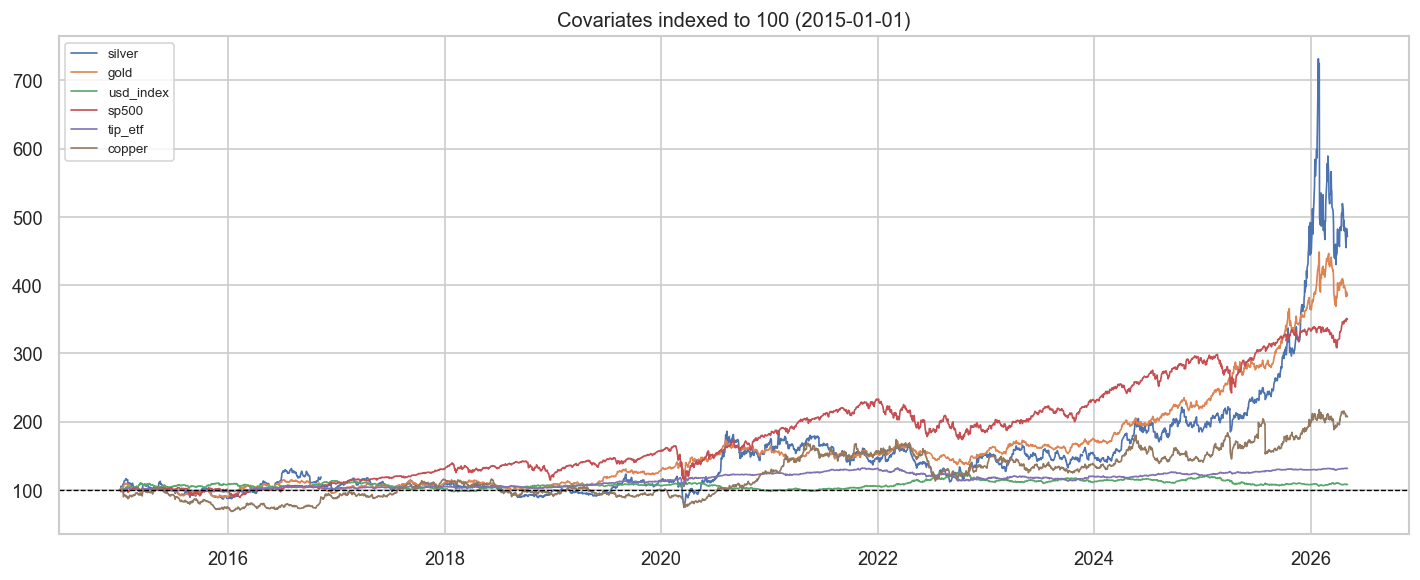

In [22]:
# Plot all daily covariates normalised to 100 at start
norm_prices = prices.div(prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in norm_prices.columns:
    ax.plot(norm_prices[col], label=col, lw=1)
ax.axhline(100, color='black', lw=0.8, linestyle='--')
ax.set_title('Covariates indexed to 100 (2015-01-01)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation matrix

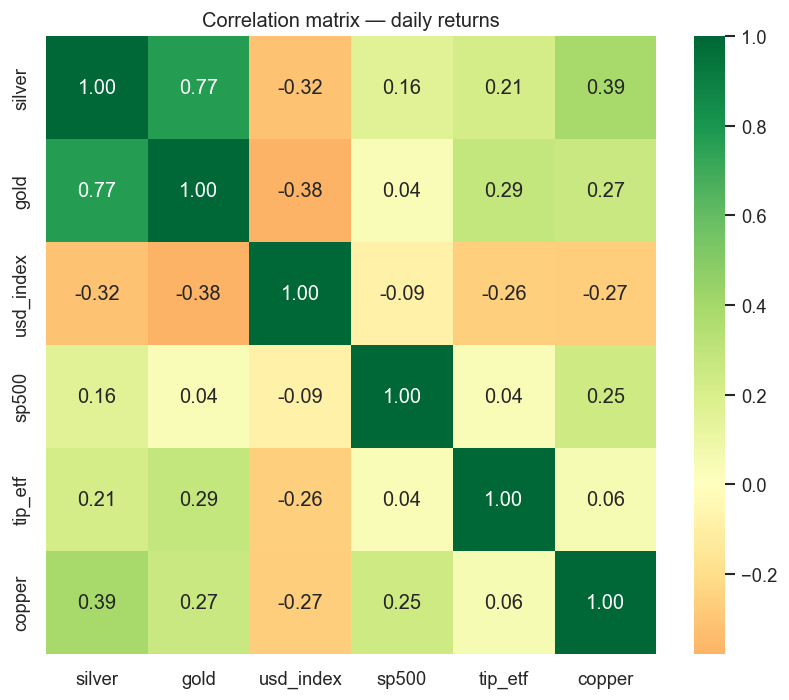

In [23]:
returns = prices.pct_change().dropna()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax)
ax.set_title('Correlation matrix — daily returns')
plt.tight_layout()
plt.show()

## 7. Gold/Silver ratio

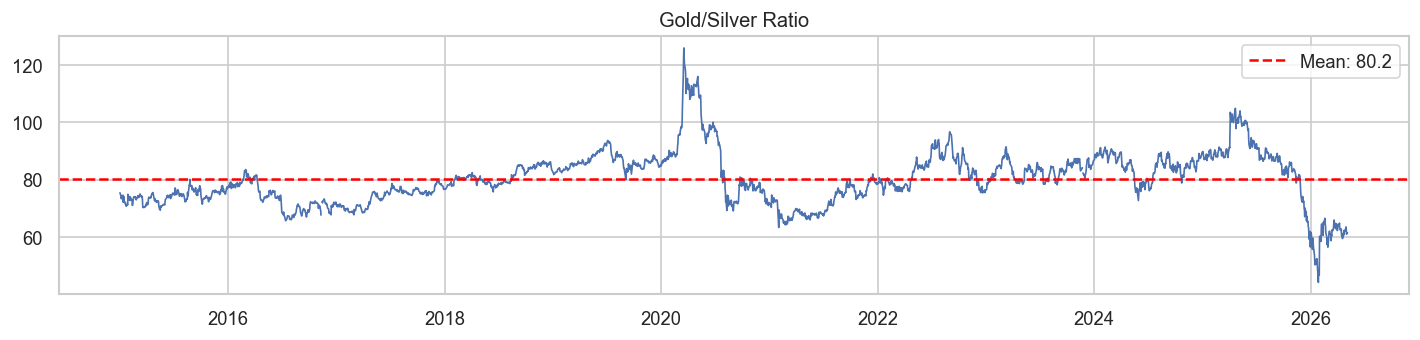

No transform applied.


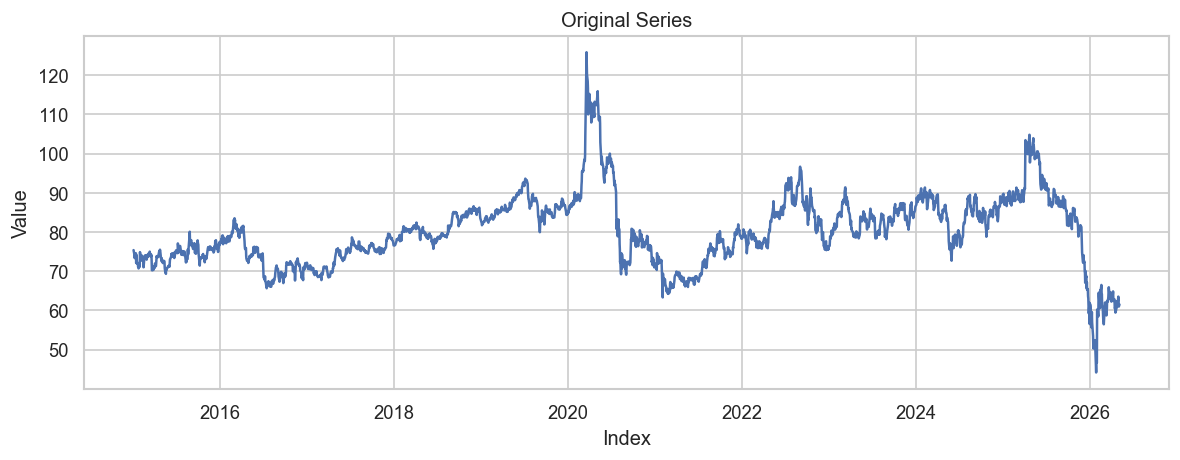

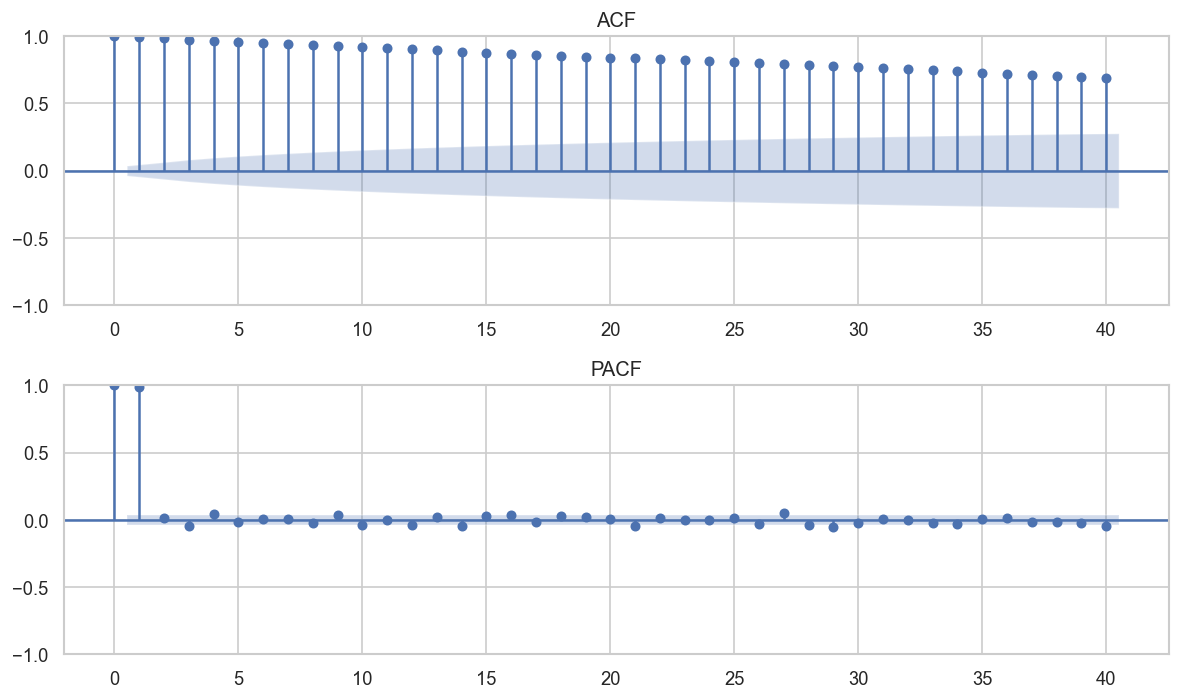

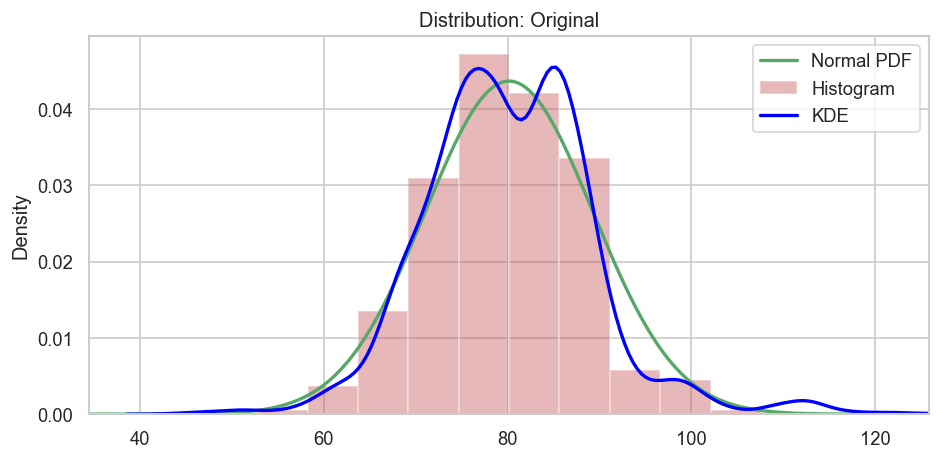

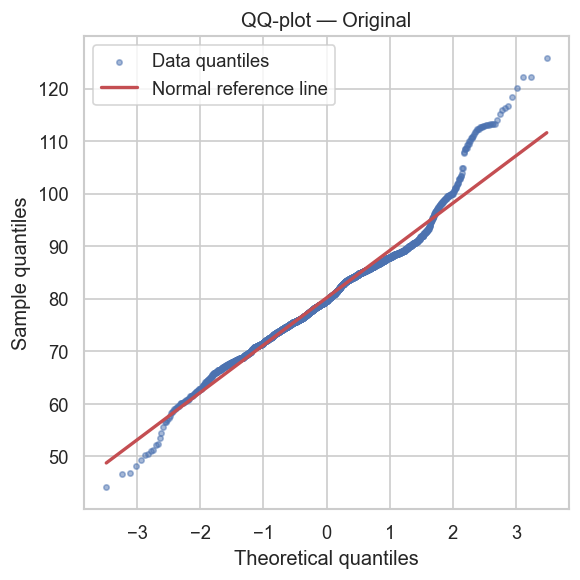

  QQ R²: 0.9707 (1.0 = perfect normal)

ADF Test:
  Statistic: -3.0327
  p-value:   0.0320
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Stationary (reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.9711, p=0.0000  → NOT normal
D'Agostino K²:        stat=245.6765, p=0.0000  → NOT normal
Anderson-Darling:     stat=12.1107
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.0552, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2709.27, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

{'transformed_series': Date
 2015-01-02    75.378161
 2015-01-05    74.411271
 2015-01-06    73.438535
 2015-01-07    73.325255
 2015-01-08    73.903739
                 ...    
 2026-04-28    62.721124
 2026-04-29    63.507946
 2026-04-30    62.756010
 2026-05-01    60.959041
 2026-05-04    61.486580
 Length: 2849, dtype: float64,
 'adf': {'stat': -3.0326666903606085,
  'pvalue': 0.03195432022014485,
  'crit': {'1%': -3.4326710150605764,
   '5%': -2.862565463281347,
   '10%': -2.5673158851415923}},
 'ljung_box':          lb_stat  lb_pvalue
 40  81743.093689        0.0,
 'shapiro': {'stat': 0.9711130730771372, 'pvalue': 1.5374462470552865e-23}}

In [24]:
gs_ratio = prices['gold'] / prices['silver']

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gs_ratio, lw=1)
ax.axhline(gs_ratio.mean(), color='red', linestyle='--', label=f'Mean: {gs_ratio.mean():.1f}')
ax.set_title('Gold/Silver Ratio')
ax.legend()
plt.tight_layout()
plt.show()

# ADF on G/S ratio — often mean-reverting
eda_transform(gs_ratio.dropna(), transform=None, lags=40)

## 8. Mixed-frequency visualisation (MIDAS motivation)

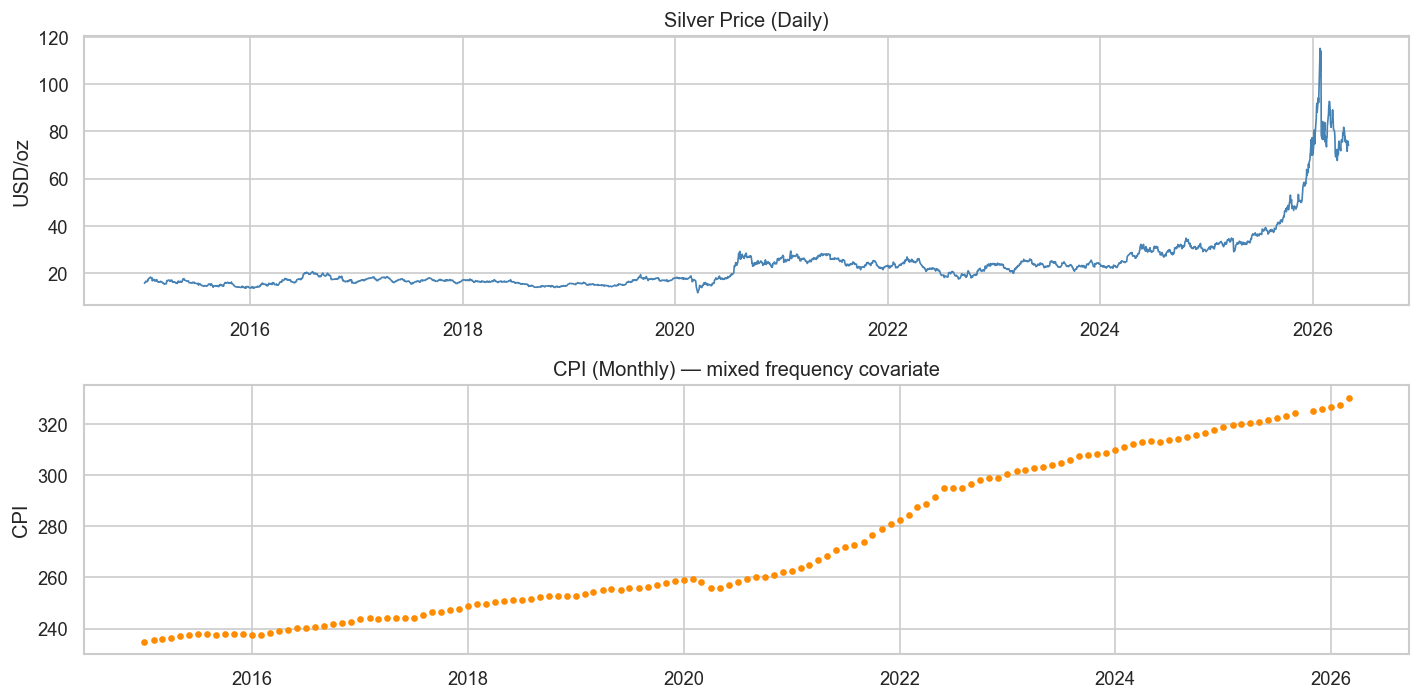

Daily obs: 2849 | Monthly obs: 2991


In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

ax1.plot(silver, lw=1, color='steelblue')
ax1.set_title('Silver Price (Daily)')
ax1.set_ylabel('USD/oz')

if 'cpi' in macro.columns:
    ax2.plot(macro['cpi'], marker='o', markersize=3, lw=1, color='darkorange')
    ax2.set_title('CPI (Monthly) — mixed frequency covariate')
    ax2.set_ylabel('CPI')

plt.tight_layout()
plt.show()
print('Daily obs:', len(silver), '| Monthly obs:', len(macro))

## 9. Weekly ACF/PACF (5-day aggregated returns)

The ARIMA model in notebook 03 operates on **weekly** log-returns
(5 trading days aggregated via `resample('W-FRI').sum()`). Before relying on
the AIC grid search to pick the order, we inspect the autocorrelation
structure of the weekly series directly.

Spikes outside the confidence bands suggest exploitable serial correlation;
a flat ACF/PACF with a non-significant Ljung-Box test would indicate
the weekly series is white noise — no ARMA structure to capture.

Weekly observations: 592


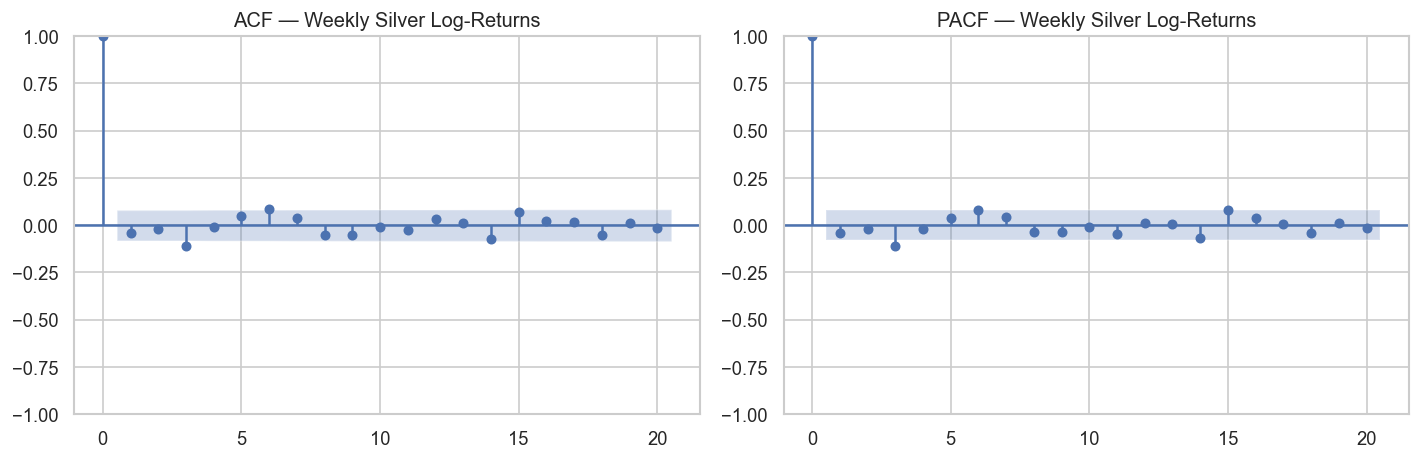


Ljung-Box test (weekly returns):
      lb_stat  lb_pvalue
5    9.616465   0.086861
10  18.094302   0.053394
20  27.550501   0.120474


In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Aggregate daily silver log-returns to weekly (Mon–Fri sum)
silver_weekly = log_returns.resample('W-FRI').sum().dropna()
print(f'Weekly observations: {len(silver_weekly)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( silver_weekly, lags=20, ax=axes[0],
          title='ACF — Weekly Silver Log-Returns')
plot_pacf(silver_weekly, lags=20, ax=axes[1],
          title='PACF — Weekly Silver Log-Returns')
plt.tight_layout()
plt.show()

# Ljung-Box test for remaining autocorrelation
lb = acorr_ljungbox(silver_weekly, lags=[5, 10, 20], return_df=True)
print('\nLjung-Box test (weekly returns):')
print(lb.to_string())


### EDA transform — Weekly Silver Log-Returns

Runs the same stationarity and distribution diagnostics as section 4 but on the
**weekly** series. Confirms the series is stationary at weekly frequency and
shows the distribution shape before feeding into `03_arima_baseline.ipynb`.


No transform applied.


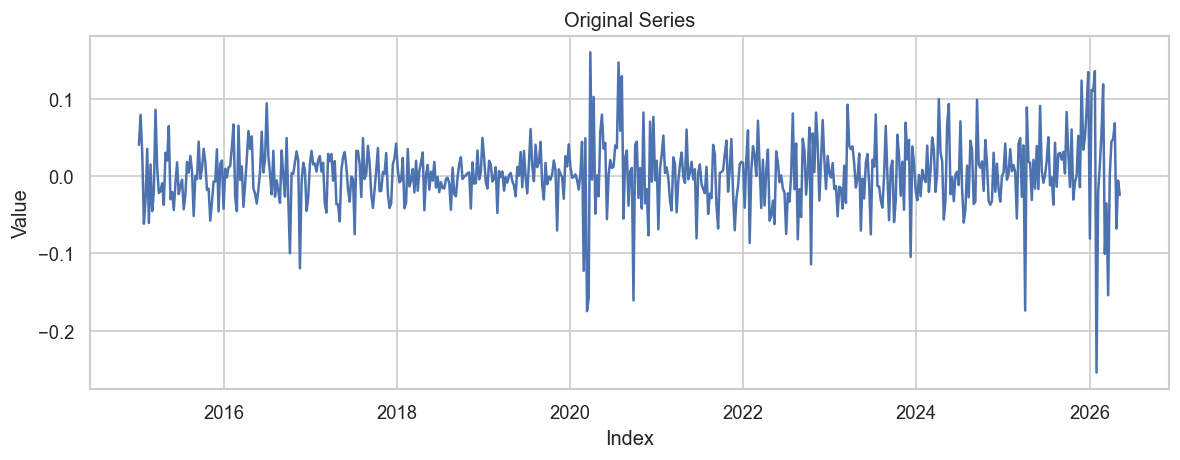

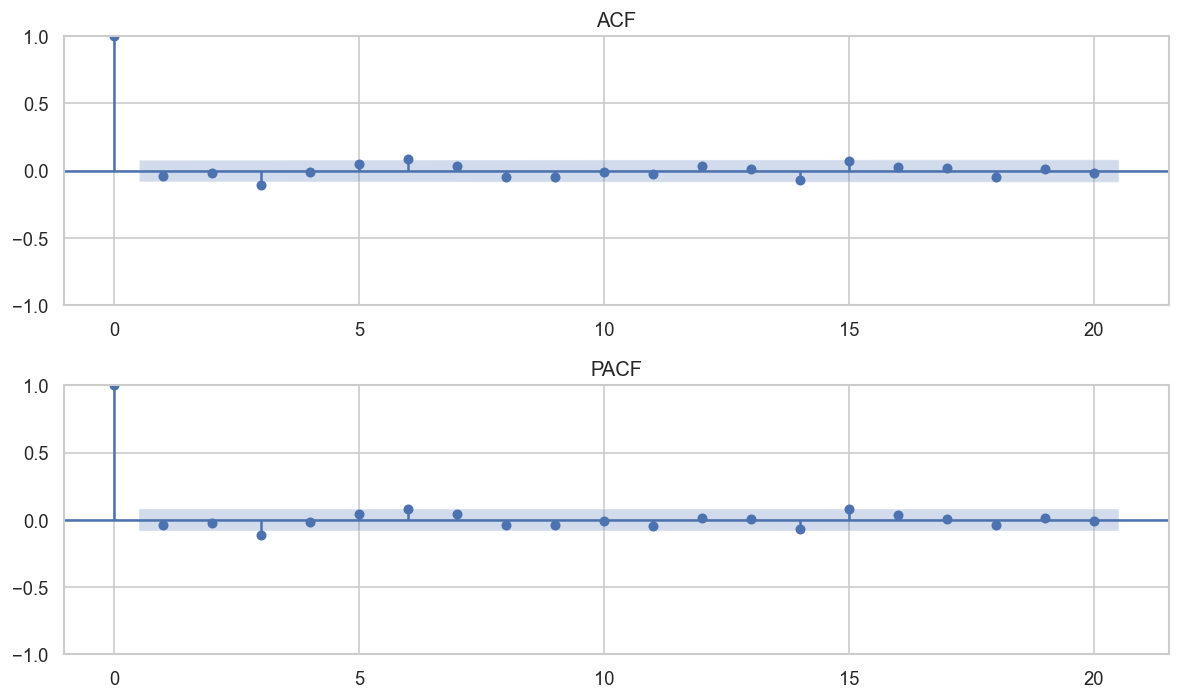

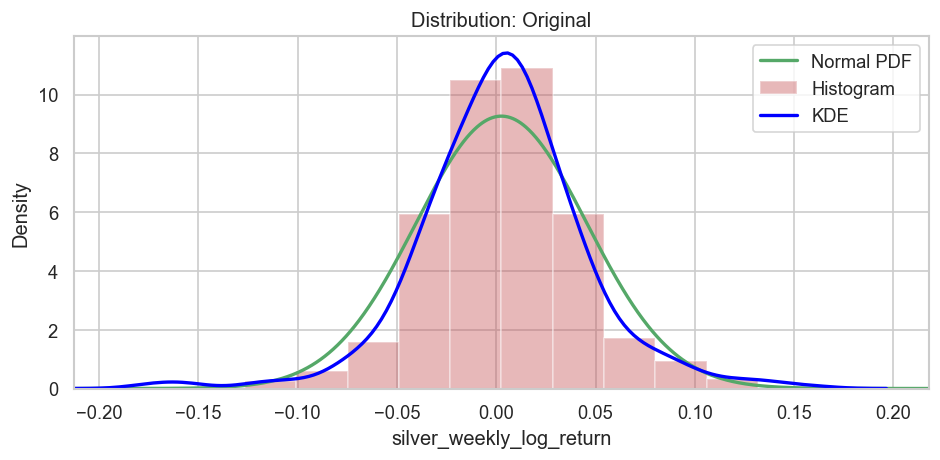

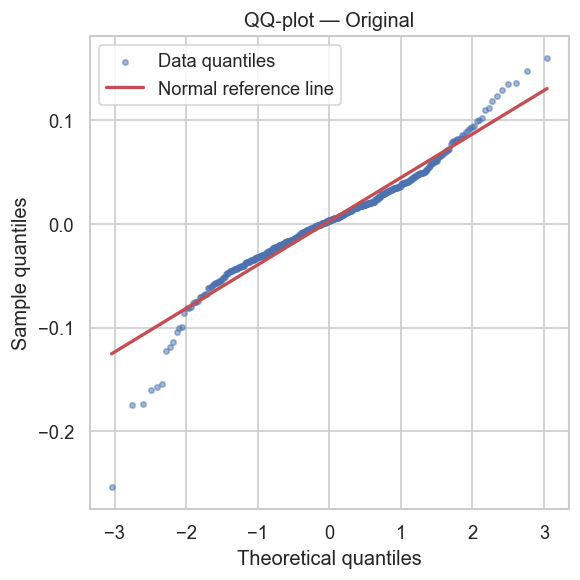

  QQ R²: 0.9461 (1.0 = perfect normal)

ADF Test:
  Statistic: -16.1387
  p-value:   0.0000
    1%: -3.4415
    5%: -2.8665
    10%: -2.5694
  → Stationary (reject H₀)

Ljung-Box (lag=20): p-value = 0.1205
  → No significant autocorrelation

Shapiro-Wilk:         stat=0.9494, p=0.0000  → NOT normal
D'Agostino K²:        stat=84.2637, p=0.0000  → NOT normal
Anderson-Darling:     stat=5.3926
     15.0%: 0.5600 ← reject normality
     10.0%: 0.6300 ← reject normality
      5.0%: 0.7510 ← reject normality
      2.5%: 0.8720 ← reject normality
      1.0%: 1.0340 ← reject normality
Kolmogorov-Smirnov:   stat=0.0645, p=0.0139  → NOT normal

ARCH LM test (nlags=12):  stat=83.14, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=20): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')


In [27]:
silver_weekly.name = 'silver_weekly_log_return'
result_weekly = eda_transform(silver_weekly, transform=None, lags=20)


### Key finding: weekly silver returns are white noise

The ACF/PACF plots above show every spike well within the 95% confidence bands at all lags,
and the Ljung-Box test returns p = 0.358 — no statistically significant autocorrelation
at any horizon up to lag 20. The AIC grid search in `03_arima_baseline.ipynb` confirms
this by selecting **ARIMA(0,0,0)** — a constant mean with white noise — as the best model.

**What this means:**

Weekly silver log-returns have no memory of their own past. Knowing last week's return
tells you nothing about this week's return. This is consistent with the **weak form of
the Efficient Market Hypothesis** (EMH): all information contained in past prices is
already reflected in the current price.

**Why this is central to the thesis:**

If silver returns cannot be predicted from their own history, any predictive power must
come from *external* information. This motivates the two main ingredients of the thesis:

1. **Market co-movements** (gold, USD, copper, S&P500 via ARIMAX and MIDAS) — do
   related asset returns contain information about next week's silver return?
2. **Retail sentiment** (Reddit via RoBERTa, news via FinBERT) — does the mood of
   retail traders provide a leading signal beyond what market variables already capture?

If sentiment adds directional accuracy on top of the ARIMAX baseline, that is evidence
against **semi-strong EMH** — public sentiment data is not fully priced in at weekly
frequency. This would support the retail-driven price hypothesis central to this thesis.


## 10. Sentiment correlation during the Silver Squeeze

The January 2021 WallStreetBets silver squeeze is the central event motivating
the retail-sentiment hypothesis. Here we test whether Reddit and news sentiment
were correlated with silver returns **inside the squeeze episode** at two lags:

- **1-day lag**: sentiment on day $t-1$ vs silver return on day $t$
- **1-week lag** (5 trading days): sentiment on day $t-5$ vs silver return on day $t$

Squeeze episode window: **October 2020 – June 2021** (~175 trading days).
Squeeze peak: **28 Jan – 5 Feb 2021** (orange shading).


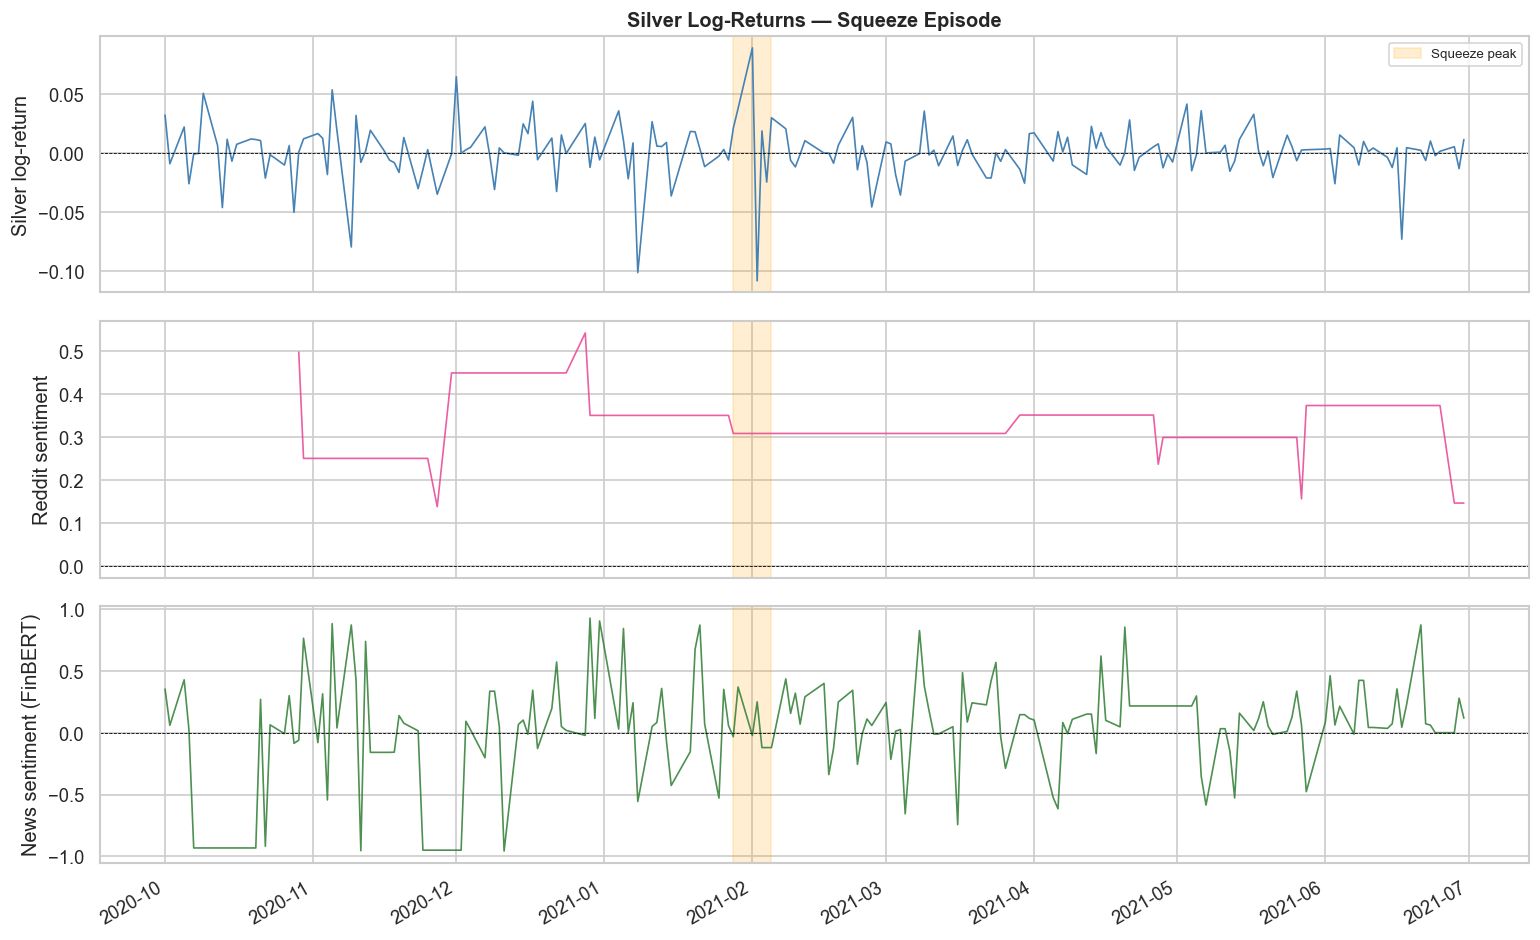

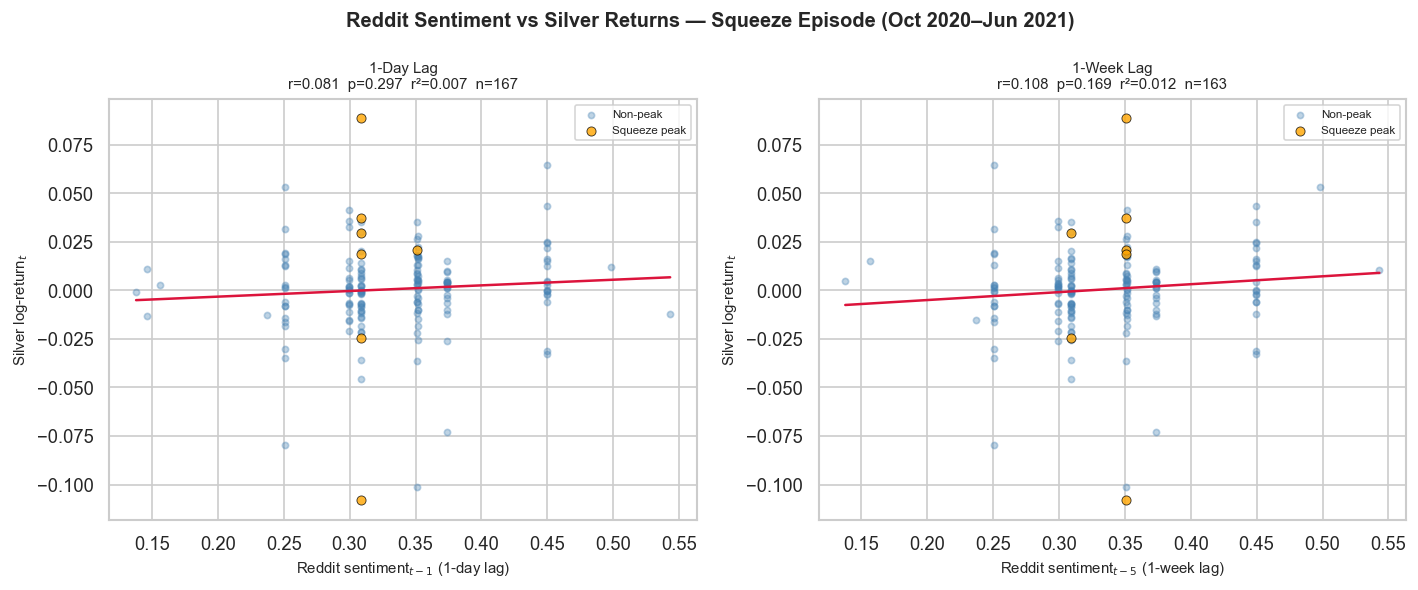

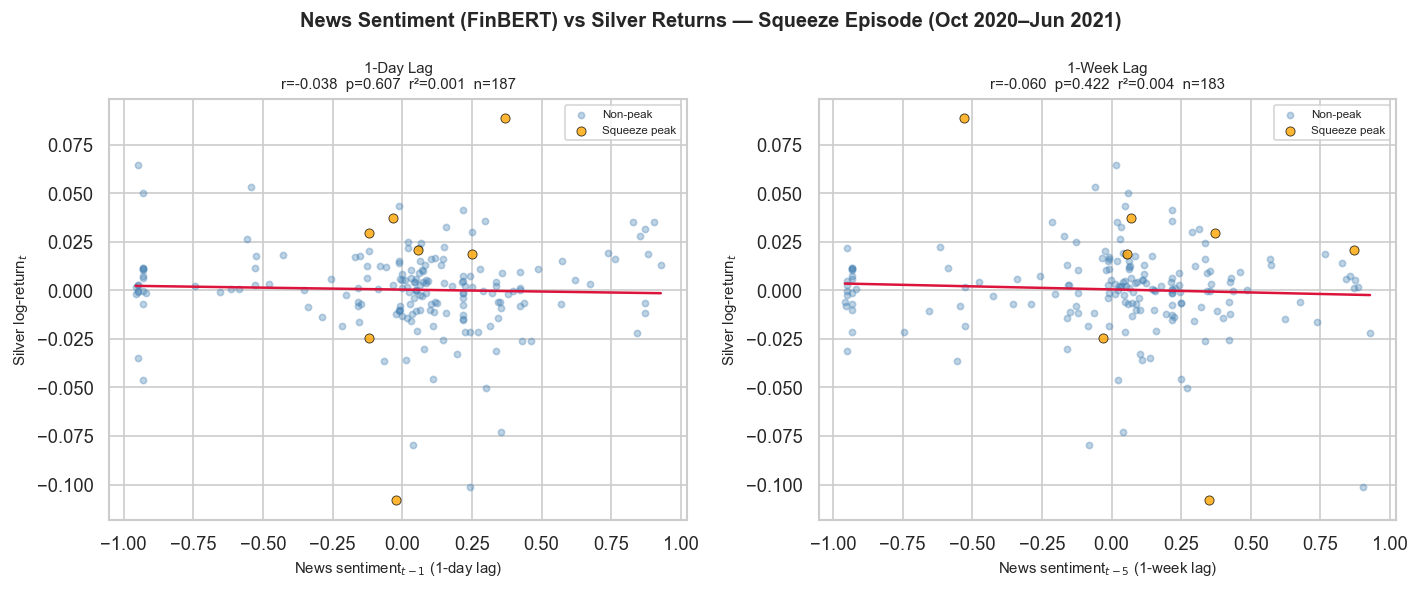


Summary — Squeeze episode correlations (Oct 2020–Jun 2021):
  Specification                                  r       r²        p
  ------------------------------------------------------------
  1-Day Lag                                  0.081    0.007    0.297
  1-Week Lag                                 0.108    0.012    0.169
  1-Day Lag                                 -0.038    0.001    0.607
  1-Week Lag                                -0.060    0.004    0.422

* p<0.05  ** p<0.01  *** p<0.001
Orange dots = squeeze peak (Jan 28 – Feb 5, 2021).
r² = fraction of silver-return variance explained by lagged sentiment.


In [29]:
from scipy import stats as scipy_stats
import os

# ── Load sentiment ────────────────────────────────────────────────────────
sent_path = '../data/processed/daily_sentiment.csv'
if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 06_sentiment.ipynb first.')
else:
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)

    # Align with silver returns (computed above in cell 9)
    silver_ret = np.log(prices['silver']).diff().dropna()
    silver_ret.index = silver_ret.index.tz_localize(None)

    # ── Squeeze episode window ────────────────────────────────────────────
    EPISODE_START = '2020-10-01'
    EPISODE_END   = '2021-06-30'
    SQUEEZE_START = pd.Timestamp('2021-01-28')
    SQUEEZE_END   = pd.Timestamp('2021-02-05')

    ret_ep   = silver_ret.loc[EPISODE_START:EPISODE_END]
    sent_ep  = sent.reindex(ret_ep.index).ffill()

    reddit = sent_ep['reddit_sentiment']
    news   = sent_ep['news_sentiment']

    # ── Panel 1: time series overview ─────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

    axes[0].plot(ret_ep.index, ret_ep.values, lw=1, color='steelblue')
    axes[0].axhline(0, color='black', lw=0.5, ls='--')
    axes[0].set_ylabel('Silver log-return')
    axes[0].set_title('Silver Log-Returns — Squeeze Episode', fontweight='bold')

    axes[1].plot(reddit.index, reddit.values, lw=1, color='#e84393', alpha=0.85)
    axes[1].axhline(0, color='black', lw=0.5, ls='--')
    axes[1].set_ylabel('Reddit sentiment')

    axes[2].plot(news.index, news.values, lw=1, color='#2e7d32', alpha=0.85)
    axes[2].axhline(0, color='black', lw=0.5, ls='--')
    axes[2].set_ylabel('News sentiment (FinBERT)')

    for ax in axes:
        ax.axvspan(SQUEEZE_START, SQUEEZE_END, alpha=0.18, color='orange',
                   label='Squeeze peak' if ax is axes[0] else None)
    axes[0].legend(fontsize=8)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # ── Helper: scatter + Pearson r ───────────────────────────────────────
    def squeeze_scatter(ax, x_series, y_series, xlabel, ylabel, title):
        df = pd.concat([x_series, y_series], axis=1).dropna()
        if len(df) < 10:
            ax.text(0.5, 0.5, f'n={len(df)} — insufficient', ha='center',
                    va='center', transform=ax.transAxes)
            ax.set_title(title); return None
        x, y = df.iloc[:, 0].values, df.iloc[:, 1].values
        r, p = scipy_stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        # colour-code: squeeze peak vs rest
        peak_mask = (df.index >= SQUEEZE_START) & (df.index <= SQUEEZE_END)
        ax.scatter(x[~peak_mask], y[~peak_mask], alpha=0.35, s=14,
                   color='steelblue', label='Non-peak')
        ax.scatter(x[peak_mask],  y[peak_mask],  alpha=0.8,  s=30,
                   color='orange', edgecolors='black', lw=0.5,
                   zorder=5, label='Squeeze peak')
        ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        r2 = r ** 2
        ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  r²={r2:.3f}  n={len(df)}',
                     fontsize=9)
        ax.legend(fontsize=7)
        return {'title': title, 'r': r, 'r2': r2, 'p': p, 'n': len(df)}

    # ── Panel 2: 2×2 scatter — Reddit ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Reddit Sentiment vs Silver Returns — Squeeze Episode (Oct 2020–Jun 2021)',
                 fontsize=12, fontweight='bold')

    r1 = squeeze_scatter(axes[0],
        reddit.shift(1), ret_ep.reindex(reddit.index),
        'Reddit sentiment$_{t-1}$ (1-day lag)',
        'Silver log-return$_t$',
        '1-Day Lag')

    r5 = squeeze_scatter(axes[1],
        reddit.shift(5), ret_ep.reindex(reddit.index),
        'Reddit sentiment$_{t-5}$ (1-week lag)',
        'Silver log-return$_t$',
        '1-Week Lag')

    plt.tight_layout()
    plt.show()

    # ── Panel 3: 2×2 scatter — News ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('News Sentiment (FinBERT) vs Silver Returns — Squeeze Episode (Oct 2020–Jun 2021)',
                 fontsize=12, fontweight='bold')

    n1 = squeeze_scatter(axes[0],
        news.shift(1), ret_ep.reindex(news.index),
        'News sentiment$_{t-1}$ (1-day lag)',
        'Silver log-return$_t$',
        '1-Day Lag')

    n5 = squeeze_scatter(axes[1],
        news.shift(5), ret_ep.reindex(news.index),
        'News sentiment$_{t-5}$ (1-week lag)',
        'Silver log-return$_t$',
        '1-Week Lag')

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────
    rows = [r for r in [r1, r5, n1, n5] if r is not None]
    if rows:
        print('\nSummary — Squeeze episode correlations (Oct 2020–Jun 2021):')
        print(f'  {"Specification":<40} {"r":>7}  {"r²":>7}  {"p":>7}')
        print('  ' + '-' * 60)
        for row in rows:
            sig = '***' if row["p"] < 0.001 else '**' if row["p"] < 0.01 else '*' if row["p"] < 0.05 else ''
            print(f'  {row["title"]:<40} {row["r"]:>7.3f}  {row["r2"]:>7.3f}  {row["p"]:>7.3f}{sig}')
        print('\n* p<0.05  ** p<0.01  *** p<0.001')
        print('Orange dots = squeeze peak (Jan 28 – Feb 5, 2021).')
        print('r² = fraction of silver-return variance explained by lagged sentiment.')
